# Single-neuron screening — Final Version

Fully standalone — no external utils.py dependency.

## Structure
1. Imports & helpers (inlined)
2. Load dataset
3. Preprocessing & phase masks
4. Event onset extraction
5. Population-level attack response (global mean ± SEM + raster)
6. Occupancy modulation — within-phase attack vs non-attack
7. Sensitivity analysis (clean pre-window)
8. White vs Dark single-cell comparison
9. Candidate PSTH gallery
10. Summary & interpretation

## Global interpretation notes
- Permutation tests use **block circular-shift** to preserve temporal autocorrelation structure.
- FDR correction (Benjamini-Hochberg) applied across all neurons within each contrast.
- `binwise` decoding is optimistic (temporally autocorrelated bins). Use occupancy results as primary.
- Single-session data — all findings require cross-session replication.

In [1]:
# =============================================================================
# SECTION 0 · Imports
# =============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.ndimage import gaussian_filter1d
from scipy.stats import rankdata
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Imports OK')

Imports OK


In [ ]:
# =============================================================================
# SECTION 0b · Inlined helpers (no utils.py required)
# =============================================================================

def cell_to_dict(cell_array):
    """Convert MATLAB cell array of {key, value} pairs to Python dict."""
    out = {}
    for i in range(len(cell_array)):
        key = str(cell_array[i][0])
        val = cell_array[i][1]
        if val.ndim == 2 and val.shape[0] == 1:
            val = val[0]
        out[key] = val
    return out


def smooth_and_zscore_fr(FR, fs=50.0, smooth_width_ms=200.0):
    smoothWidth_bins = round((smooth_width_ms / 1000.0) * fs)  # = 10
    sigma_bins = smoothWidth_bins / 3                           # = 3.0，和MATLAB一致
    FR_smooth = gaussian_filter1d(FR.astype(float), sigma=sigma_bins,
                                  axis=1, mode="nearest")
    mu = FR_smooth.mean(axis=1, keepdims=True)
    sd = FR_smooth.std(axis=1,  keepdims=True)
    sd[sd == 0] = 1.0
    FRz = (FR_smooth - mu) / sd
    FRz[~np.isfinite(FRz)] = 0.0
    return FR_smooth, FRz

def build_phase_masks_from_gate(gate_open, fs=50.0, white_minutes=5, dark_minutes=5):
    """Build Pre / WhiteAgg / DarkAgg / Post phase masks."""
    nT = len(gate_open)
    gate_start = int(np.argmax(gate_open))
    white_bins = int(white_minutes * 60 * fs)
    dark_bins  = int(dark_minutes  * 60 * fs)
    white_start = gate_start
    white_end   = min(white_start + white_bins - 1, nT - 1)
    dark_start  = white_end + 1
    dark_end    = min(dark_start + dark_bins - 1, nT - 1)
    post_start  = dark_end + 1
    masks = {k: np.zeros(nT, dtype=bool) for k in ['Pre', 'WhiteAgg', 'DarkAgg', 'Post']}
    masks['Pre'][:white_start]             = True
    masks['WhiteAgg'][white_start:white_end+1] = True
    masks['DarkAgg'][dark_start:dark_end+1]    = True
    masks['Post'][post_start:]             = True
    return masks


def get_onsets_from_binary_mask(mask):
    """Return indices where mask transitions 0→1."""
    mask = mask.astype(int)
    diff = np.diff(np.concatenate([[0], mask]))
    return np.where(diff == 1)[0]


def get_bouts_from_binary_mask(mask):
    """Return (start, end) pairs for each bout."""
    onsets  = get_onsets_from_binary_mask(mask)
    offsets = get_onsets_from_binary_mask(~mask)
    bouts = []
    for on in onsets:
        off_candidates = offsets[offsets > on]
        off = off_candidates[0] - 1 if len(off_candidates) else len(mask) - 1
        bouts.append((on, off))
    return bouts


def bouts_summary(mask, fs=50.0):
    """Compute n_bouts, total_duration_s, mean_duration_s, mean_isi_s."""
    bouts = get_bouts_from_binary_mask(mask)
    if not bouts:
        return dict(n_bouts=0, total_duration_s=0, mean_duration_s=np.nan, mean_isi_s=np.nan)
    durations = [(e - s + 1) / fs for s, e in bouts]
    isis = [(bouts[i+1][0] - bouts[i][1]) / fs for i in range(len(bouts)-1)]
    return dict(
        n_bouts=len(bouts),
        total_duration_s=sum(durations),
        mean_duration_s=np.mean(durations),
        mean_isi_s=np.mean(isis) if isis else np.nan,
    )


def filter_onsets_by_phase_and_window(onsets, phase_mask, nT, pre_bins, post_bins):
    """Keep onsets inside phase and with enough pre/post room."""
    return np.array([
        o for o in onsets
        if phase_mask[o] and o >= pre_bins and o + post_bins < nT
    ])


def filter_clean_pre_onsets(onsets, event_mask, pre_bins):
    """Keep onsets where the pre-window contains no other events."""
    return np.array([
        o for o in onsets
        if not event_mask[max(0, o - pre_bins):o].any()
    ])


def extract_event_windows(FRz, onsets, pre_bins, post_bins):
    """Return array of shape (n_events, n_neurons, n_time)."""
    n_neurons = FRz.shape[0]
    win_len = pre_bins + post_bins + 1
    out = np.zeros((len(onsets), n_neurons, win_len))
    for i, o in enumerate(onsets):
        out[i] = FRz[:, o - pre_bins: o + post_bins + 1]
    return out


def _fdr_bh(pvals):
    """Benjamini-Hochberg FDR correction. Returns q-values."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranks = np.empty(n)
    ranks[order] = np.arange(1, n+1)
    q = pvals * n / ranks
    # make monotone from right
    q_mono = np.minimum.accumulate(q[order][::-1])[::-1]
    q_out = np.empty(n)
    q_out[order] = np.minimum(q_mono, 1.0)
    return q_out


def _block_circular_shift(arr, block_size, rng):
    """Circular shift arr by a random multiple of block_size."""
    n = len(arr)
    n_blocks = n // block_size
    shift = rng.integers(1, max(n_blocks, 2)) * block_size
    return np.roll(arr, shift)


def _compute_metric(windows, neuron_idx, pre_bins, response_bins, metric):
    """Compute effect metric for one neuron across events."""
    r0, r1 = response_bins
    resp = windows[:, neuron_idx, pre_bins + r0: pre_bins + r1 + 1].mean(axis=1)
    base = windows[:, neuron_idx, :pre_bins].mean(axis=1)
    delta = resp - base
    if metric == 'mean_delta':
        return float(delta.mean())
    elif metric == 'peak_abs_signed':
        mean_trace = windows[:, neuron_idx, :].mean(axis=0)
        peak_idx = np.argmax(np.abs(mean_trace[pre_bins + r0: pre_bins + r1 + 1]))
        return float(mean_trace[pre_bins + r0 + peak_idx] - mean_trace[:pre_bins].mean())
    return float(delta.mean())


def occupancy_modulation_by_phase(
    FRz, event_mask, phase_mask,
    n_perm=2000, alpha=0.05, min_effect=0.15, seed=0
):
    """
    For each neuron, compare mean z-score during event bins vs non-event bins,
    both restricted to phase_mask. Block circular-shift permutation + FDR.
    """
    rng = np.random.default_rng(seed)
    n_neurons = FRz.shape[0]
    in_phase = phase_mask
    event_in_phase   = event_mask & in_phase
    nonevent_in_phase = (~event_mask) & in_phase

    rows = []
    for nid in range(n_neurons):
        trace = FRz[nid]
        obs_diff = trace[event_in_phase].mean() - trace[nonevent_in_phase].mean()
        block_size = max(1, int(FRz.shape[1] * 0.01))  # ~1% of session
        null = []
        for _ in range(n_perm):
            shifted = _block_circular_shift(event_mask.astype(float), block_size, rng).astype(bool)
            s_ev  = shifted & in_phase
            s_non = (~shifted) & in_phase
            if s_ev.sum() == 0 or s_non.sum() == 0:
                null.append(0.0)
                continue
            null.append(trace[s_ev].mean() - trace[s_non].mean())
        null = np.array(null)
        p_two = float(np.mean(np.abs(null) >= np.abs(obs_diff)))
        rows.append(dict(
            neuron=nid,
            effect_diff=float(obs_diff),
            p_perm=p_two,
        ))

    df = pd.DataFrame(rows)
    df['q_fdr'] = _fdr_bh(df['p_perm'].values)
    df['significant'] = (df['q_fdr'] <= alpha) & (df['effect_diff'].abs() >= min_effect)
    df['responsive_up']   = df['significant'] & (df['effect_diff'] > 0)
    df['responsive_down'] = df['significant'] & (df['effect_diff'] < 0)

    summary = dict(
        n_significant=int(df['significant'].sum()),
        n_up=int(df['responsive_up'].sum()),
        n_down=int(df['responsive_down'].sum()),
        n_neurons=n_neurons,
    )
    return df, summary


def compare_two_conditions_delta_robust(
    FRz, onsets_a, onsets_b,
    pre_bins, post_bins, response_bins=(0, 50),
    metric='mean_delta', n_perm=5000, alpha=0.05, min_effect=0.15, seed=0
):
    """
    For each neuron, compare effect size between condition A and condition B.
    Permutation: shuffle event labels between the two onset lists.
    """
    rng = np.random.default_rng(seed)
    n_neurons = FRz.shape[0]
    windows_a = extract_event_windows(FRz, onsets_a, pre_bins, post_bins)
    windows_b = extract_event_windows(FRz, onsets_b, pre_bins, post_bins)
    na, nb = len(onsets_a), len(onsets_b)
    windows_all = np.concatenate([windows_a, windows_b], axis=0)

    rows = []
    for nid in range(n_neurons):
        eff_a = _compute_metric(windows_a, nid, pre_bins, response_bins, metric) if na > 0 else 0.0
        eff_b = _compute_metric(windows_b, nid, pre_bins, response_bins, metric) if nb > 0 else 0.0
        obs_diff = eff_a - eff_b
        null = []
        for _ in range(n_perm):
            idx = rng.permutation(na + nb)
            wa = windows_all[idx[:na]]
            wb = windows_all[idx[na:]]
            da = _compute_metric(wa, nid, pre_bins, response_bins, metric) if na > 0 else 0.0
            db = _compute_metric(wb, nid, pre_bins, response_bins, metric) if nb > 0 else 0.0
            null.append(da - db)
        null = np.array(null)
        p_two = float(np.mean(np.abs(null) >= np.abs(obs_diff)))
        rows.append(dict(
            neuron=nid,
            effect_a=float(eff_a),
            effect_b=float(eff_b),
            effect_diff_a_minus_b=float(obs_diff),
            p_perm=p_two,
        ))

    df = pd.DataFrame(rows)
    df['q_fdr'] = _fdr_bh(df['p_perm'].values)
    df['significant'] = (df['q_fdr'] <= alpha) & (df['effect_diff_a_minus_b'].abs() >= min_effect)
    return df


print('All helpers defined.')

All helpers defined.


## 1. Load dataset

In [3]:
# =============================================================================
# SECTION 1 · Load dataset
# =============================================================================
DATA_DIR = Path('.')   # ← set to folder containing neuralData.mat etc.

N = sio.loadmat(DATA_DIR / 'neuralData.mat',    squeeze_me=True, struct_as_record=False)
P = sio.loadmat(DATA_DIR / 'peripheralData.mat', squeeze_me=True, struct_as_record=False)
B = sio.loadmat(DATA_DIR / 'behaviorData.mat',   squeeze_me=True, struct_as_record=False)

FR    = N['FR']
periph = cell_to_dict(P['peripheralData'])
behav  = cell_to_dict(B['behaviorData'])

print(f'FR shape: {FR.shape}  →  {FR.shape[0]} neurons × {FR.shape[1]} bins')
print('Peripheral keys:', list(periph.keys()))
print('Behavior keys:',   list(behav.keys()))

FR shape: (218, 60000)  →  218 neurons × 60000 bins
Peripheral keys: ['gateOpen', 'whiteLight', 'ctBudSniff', 'lickEmpty', 'lickMilk']
Behavior keys: ['attackOfIntLeft', 'attackOfIntRight', 'chaseOfIntLeft', 'chaseOfIntRight', 'submissionSignFromIntLeft', 'submissionSignFromIntRight', 'attackDark']


## 2. Preprocessing & phase masks

In [4]:
# =============================================================================
# SECTION 2 · Preprocessing
# =============================================================================
fs = 50.0
n_neurons, nT = FR.shape
t_sec = np.arange(nT) / fs
t_min = t_sec / 60.0

# --- behaviour ---
attack_left  = behav['attackOfIntLeft'].astype(bool)
attack_right = behav['attackOfIntRight'].astype(bool)
attack_dark  = behav['attackDark'].astype(bool)
attack       = attack_left | attack_right | attack_dark
attack_white = (attack_left | attack_right)  # visual-phase only

submission = (behav['submissionSignFromIntLeft'].astype(bool) |
              behav['submissionSignFromIntRight'].astype(bool))
chase      = (behav['chaseOfIntLeft'].astype(bool) |
              behav['chaseOfIntRight'].astype(bool))

# --- peripheral ---
white_light = periph['whiteLight'].astype(bool)
gate_open   = periph['gateOpen'].astype(bool)
sniff_urine = periph['ctBudSniff'].astype(bool)
lick_milk   = periph['lickMilk'].astype(bool)
lick_empty  = periph['lickEmpty'].astype(bool)

# --- smoothing & z-score ---
FR_smooth, FRz = smooth_and_zscore_fr(FR, fs=fs, smooth_width_ms=200.0)

# --- phase masks ---
phase_masks = build_phase_masks_from_gate(gate_open, fs=fs, white_minutes=5, dark_minutes=5)

print(f'n_neurons={n_neurons}, n_timebins={nT}, duration(min)={nT/fs/60:.2f}')
print('Phase bin counts:', {k: int(v.sum()) for k, v in phase_masks.items()})

n_neurons=218, n_timebins=60000, duration(min)=20.00
Phase bin counts: {'Pre': 17268, 'WhiteAgg': 15000, 'DarkAgg': 15000, 'Post': 12732}


## 3. Behaviour event summary

In [5]:
# =============================================================================
# SECTION 3 · Behaviour event summary
# =============================================================================
event_masks = {
    'attack (all)':   attack,
    'attack (white)': attack_white,
    'attack (dark)':  attack_dark,
    'submission':     submission,
    'chase':          chase,
    'sniff_urine':    sniff_urine,
    'lick_milk':      lick_milk,
    'lick_empty':     lick_empty,
}
bout_summary = pd.DataFrame(
    [{'event': name, **bouts_summary(mask, fs=fs)} for name, mask in event_masks.items()]
).sort_values('n_bouts', ascending=False).reset_index(drop=True)
display(bout_summary)

,event,n_bouts,total_duration_s,mean_duration_s,mean_isi_s
0,attack (all),106,77.1200,0.7275,7.1507
1,attack (dark),68,40.0000,0.5882,7.2928
2,lick_empty,66,11.6000,0.1758,16.2262
3,submission,55,111.2200,2.0222,3.3485
4,attack (white),38,37.1200,0.9768,6.9281
5,sniff_urine,38,35.5400,0.9353,23.0914
6,lick_milk,9,20.5800,2.2867,134.5225
7,chase,8,2.6800,0.3350,38.5657


## 4. Event onset extraction

In [6]:
# =============================================================================
# SECTION 4 · Event onset extraction
# =============================================================================
pre_sec  = 1.0
post_sec = 2.0
pre_bins  = int(round(pre_sec  * fs))
post_bins = int(round(post_sec * fs))
all_time  = np.ones(nT, dtype=bool)

attack_onsets_white = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(attack_white), phase_masks['WhiteAgg'], nT, pre_bins, post_bins)
attack_onsets_dark = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(attack_dark),  phase_masks['DarkAgg'],  nT, pre_bins, post_bins)
attack_left_onsets  = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(attack_left),  phase_masks['WhiteAgg'], nT, pre_bins, post_bins)
attack_right_onsets = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(attack_right), phase_masks['WhiteAgg'], nT, pre_bins, post_bins)

sniff_onsets = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(sniff_urine), all_time, nT, pre_bins, post_bins)
milk_onsets  = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(lick_milk),   all_time, nT, pre_bins, post_bins)
empty_onsets = filter_onsets_by_phase_and_window(
    get_onsets_from_binary_mask(lick_empty),  all_time, nT, pre_bins, post_bins)

onset_counts = pd.Series({
    'attack_white': len(attack_onsets_white),
    'attack_dark':  len(attack_onsets_dark),
    'attack_left':  len(attack_left_onsets),
    'attack_right': len(attack_right_onsets),
    'sniff_urine':  len(sniff_onsets),
    'lick_milk':    len(milk_onsets),
    'lick_empty':   len(empty_onsets),
}, name='n_onsets')
print(onset_counts.to_string())

attack_white    38
attack_dark     33
attack_left     26
attack_right    12
sniff_urine     38
lick_milk        9
lick_empty      66


## 5. Population-level attack response

Before looking at single cells, establish what the population does.
Two views: (1) global mean ± SEM across all neurons, (2) full neuron × time raster.

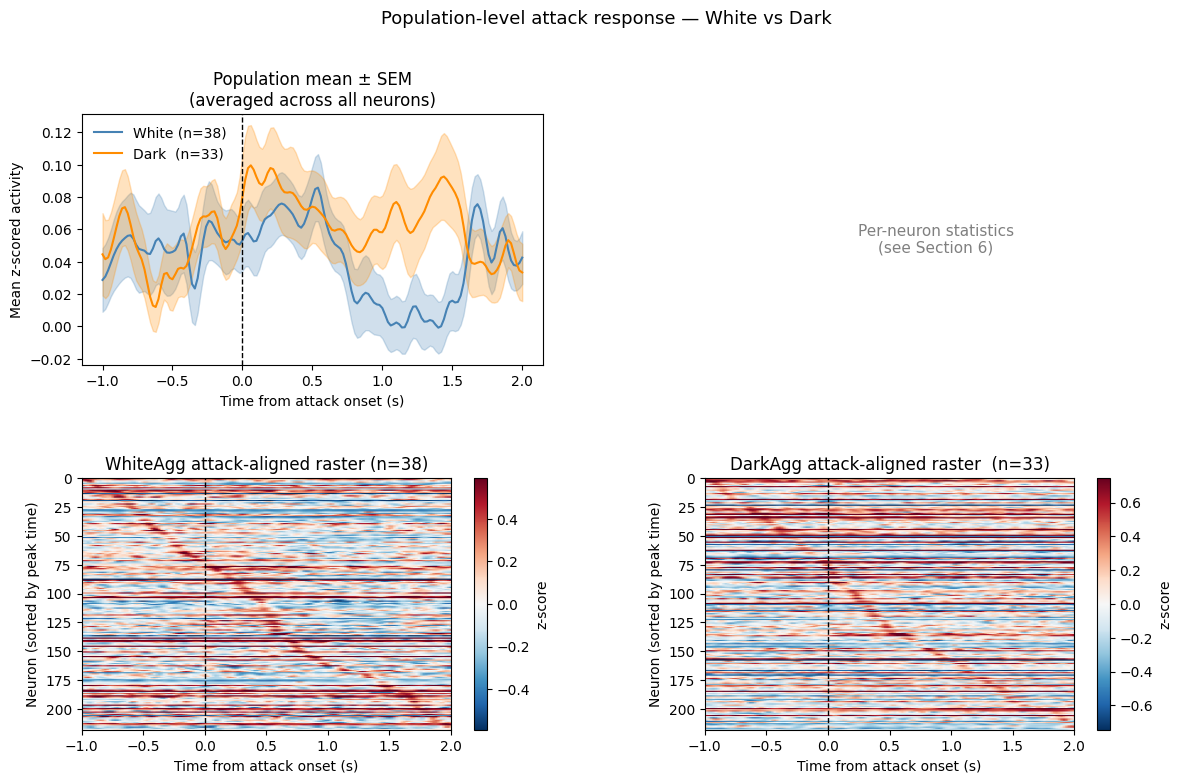

Interpretation:
  Attack onset drives a clear population response in both White and Dark conditions.
  Whether this reflects behaviour or context requires single-cell analysis.


In [7]:
# =============================================================================
# SECTION 5 · Population-level attack response
# =============================================================================
time_event = np.arange(-pre_bins, post_bins + 1) / fs

windows_white = extract_event_windows(FRz, attack_onsets_white, pre_bins, post_bins)
windows_dark  = extract_event_windows(FRz, attack_onsets_dark,  pre_bins, post_bins)

# global mean across neurons then across events
# shape: (n_events, n_neurons, n_time) → mean over neurons → (n_events, n_time) → mean over events
def pop_mean_sem(windows):
    """Mean and SEM of population-averaged response across events."""
    pop_per_event = windows.mean(axis=1)          # (n_events, n_time)
    mean = pop_per_event.mean(axis=0)
    sem  = pop_per_event.std(axis=0, ddof=1) / np.sqrt(max(pop_per_event.shape[0], 1))
    return mean, sem

mean_w, sem_w = pop_mean_sem(windows_white)
mean_d, sem_d = pop_mean_sem(windows_dark)

# neuron × time raster: mean across events, then sort by peak response time
def raster_matrix(windows):
    """Return (n_neurons, n_time) matrix, sorted by peak time."""
    mat = windows.mean(axis=0)                    # (n_neurons, n_time)
    peak_times = np.argmax(mat, axis=1)
    order = np.argsort(peak_times)
    return mat[order]

raster_w = raster_matrix(windows_white)
raster_d = raster_matrix(windows_dark)

# --- Plot ---
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Top row: mean ± SEM
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(time_event, mean_w, color='steelblue',  label=f'White (n={len(attack_onsets_white)})')
ax0.fill_between(time_event, mean_w - sem_w, mean_w + sem_w, alpha=0.25, color='steelblue')
ax0.plot(time_event, mean_d, color='darkorange', label=f'Dark  (n={len(attack_onsets_dark)})')
ax0.fill_between(time_event, mean_d - sem_d, mean_d + sem_d, alpha=0.25, color='darkorange')
ax0.axvline(0, color='k', linestyle='--', linewidth=1)
ax0.set_xlabel('Time from attack onset (s)')
ax0.set_ylabel('Mean z-scored activity')
ax0.set_title('Population mean ± SEM\n(averaged across all neurons)')
ax0.legend(frameon=False)

# Bottom row: rasters
for ax, raster, title in [
    (fig.add_subplot(gs[1, 0]), raster_w, f'WhiteAgg attack-aligned raster (n={len(attack_onsets_white)})'),
    (fig.add_subplot(gs[1, 1]), raster_d, f'DarkAgg attack-aligned raster  (n={len(attack_onsets_dark)})'),
]:
    vmax = np.percentile(np.abs(raster), 95)
    im = ax.imshow(
        raster, aspect='auto', cmap='RdBu_r',
        extent=[time_event[0], time_event[-1], n_neurons, 0],
        vmin=-vmax, vmax=vmax
    )
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel('Time from attack onset (s)')
    ax.set_ylabel('Neuron (sorted by peak time)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='z-score')

# Top-right: placeholder for per-neuron summary (filled in Section 6)
ax_ph = fig.add_subplot(gs[0, 1])
ax_ph.axis('off')
ax_ph.text(0.5, 0.5, 'Per-neuron statistics\n(see Section 6)',
           ha='center', va='center', fontsize=11, color='gray')

plt.suptitle('Population-level attack response — White vs Dark', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Attack onset drives a clear population response in both White and Dark conditions.')
print('  Whether this reflects behaviour or context requires single-cell analysis.')

## 6. Occupancy modulation — within-phase attack vs non-attack

Primary analysis: for each neuron, compare mean firing rate during attack bins
vs non-attack bins **within the same phase**. This controls for phase-level
drift and directly tests behaviour-linked modulation.

Permutation: block circular-shift preserves temporal autocorrelation.
FDR correction (Benjamini-Hochberg) across all neurons.

In [8]:
# =============================================================================
# SECTION 6 · Occupancy modulation
# =============================================================================
occ_white_df, occ_white_summary = occupancy_modulation_by_phase(
    FRz, attack_white, phase_masks['WhiteAgg'], n_perm=2000, alpha=0.05, min_effect=0.15, seed=0)
occ_dark_df, occ_dark_summary = occupancy_modulation_by_phase(
    FRz, attack_dark, phase_masks['DarkAgg'],   n_perm=2000, alpha=0.05, min_effect=0.15, seed=0)

occupancy_summary = pd.DataFrame([
    {'condition': 'White attack vs non-attack', **occ_white_summary},
    {'condition': 'Dark attack vs non-attack',  **occ_dark_summary},
])
display(occupancy_summary)

,condition,n_significant,n_up,n_down,n_neurons
0,White attack vs non-attack,1,1,0,218
1,Dark attack vs non-attack,0,0,0,218


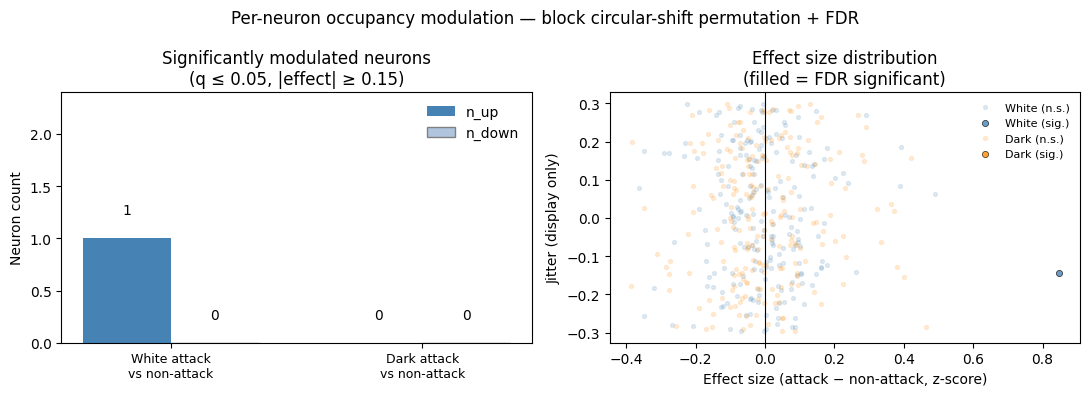

In [9]:
# --- Per-neuron modulation summary bar chart (PPT Slide 6 figure) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

conditions  = ['White attack\nvs non-attack', 'Dark attack\nvs non-attack']
summaries   = [occ_white_summary, occ_dark_summary]
colors_up   = ['steelblue', 'darkorange']
colors_down = ['lightsteelblue', 'moccasin']

# Left: n_up / n_down per condition
ax = axes[0]
x = np.arange(len(conditions))
width = 0.35
n_up   = [s['n_up']   for s in summaries]
n_down = [s['n_down'] for s in summaries]
ax.bar(x - width/2, n_up,   width, label='n_up',   color=['steelblue', 'darkorange'])
ax.bar(x + width/2, n_down, width, label='n_down',
       color=['lightsteelblue', 'moccasin'], edgecolor='gray')
ax.set_xticks(x); ax.set_xticklabels(conditions, fontsize=9)
ax.set_ylabel('Neuron count')
ax.set_title('Significantly modulated neurons\n(q ≤ 0.05, |effect| ≥ 0.15)')
ax.legend(frameon=False)
ax.set_ylim(0, max(n_up + n_down) * 1.4 + 1)
for i, (u, d) in enumerate(zip(n_up, n_down)):
    ax.text(i - width/2, u + 0.2, str(u), ha='center', va='bottom', fontsize=10)
    ax.text(i + width/2, d + 0.2, str(d), ha='center', va='bottom', fontsize=10)

# Right: effect size distribution
ax2 = axes[1]
for df, color, label in [
    (occ_white_df, 'steelblue',  'White'),
    (occ_dark_df,  'darkorange', 'Dark'),
]:
    sig = df[df['significant']]['effect_diff']
    ns  = df[~df['significant']]['effect_diff']
    ax2.scatter(ns,  np.random.default_rng(1).uniform(-0.3, 0.3, len(ns)),
                color=color, alpha=0.15, s=8, label=f'{label} (n.s.)')
    ax2.scatter(sig, np.random.default_rng(2).uniform(-0.3, 0.3, len(sig)),
                color=color, alpha=0.8, s=20, edgecolors='black', linewidths=0.5,
                label=f'{label} (sig.)')
ax2.axvline(0, color='k', linewidth=0.8)
ax2.set_xlabel('Effect size (attack − non-attack, z-score)')
ax2.set_ylabel('Jitter (display only)')
ax2.set_title('Effect size distribution\n(filled = FDR significant)')
ax2.legend(frameon=False, fontsize=8)

plt.suptitle('Per-neuron occupancy modulation — block circular-shift permutation + FDR',
             fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Top modulated neurons in White phase
print('Top 10 White-phase attack-modulated neurons:')
display(occ_white_df.sort_values(['q_fdr', 'effect_diff'], ascending=[True, False]).head(10))

print('\nTop 10 Dark-phase attack-modulated neurons:')
display(occ_dark_df.sort_values(['q_fdr', 'effect_diff'], ascending=[True, False]).head(10))

Top 10 White-phase attack-modulated neurons:


,neuron,effect_diff,p_perm,q_fdr,significant,responsive_up,responsive_down
194,194,0.8461,0.0000,0.0000,True,True,False
31,31,-0.1195,0.0000,0.0000,False,False,False
189,189,0.4903,0.1090,0.4958,False,False,False
104,104,0.3921,0.1175,0.4958,False,False,False
67,67,0.3879,0.2940,0.4958,False,False,False
1,1,0.2918,0.0175,0.4958,False,False,False
94,94,0.2613,0.0860,0.4958,False,False,False
100,100,0.2390,0.0690,0.4958,False,False,False
114,114,0.2254,0.2945,0.4958,False,False,False
76,76,0.2023,0.3840,0.4958,False,False,False



Top 10 Dark-phase attack-modulated neurons:


,neuron,effect_diff,p_perm,q_fdr,significant,responsive_up,responsive_down
194,194,0.4636,0.0070,0.6861,False,False,False
113,113,0.4215,0.2110,0.6861,False,False,False
109,109,0.4012,0.0680,0.6861,False,False,False
179,179,0.3808,0.1060,0.6861,False,False,False
214,214,0.3720,0.0790,0.6861,False,False,False
200,200,0.3628,0.0975,0.6861,False,False,False
92,92,0.3340,0.0405,0.6861,False,False,False
212,212,0.3225,0.3175,0.6861,False,False,False
72,72,0.2926,0.0835,0.6861,False,False,False
180,180,0.2840,0.1030,0.6861,False,False,False


## 7. White vs Dark single-cell comparison

**Key question for PPT Slide 6:** Do any individual neurons carry the context
(White vs Dark) signal that makes the population-level decoding 100%?

Method: for each neuron, compare event-aligned response magnitude between
White attack and Dark attack. Label-shuffle permutation + FDR.

White vs Dark contrast:
  Neurons with q ≤ 0.05 and |effect| ≥ 0.15: 0 / 218



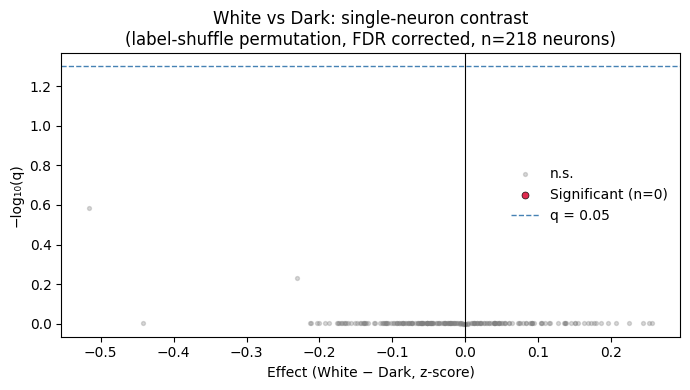

Interpretation:
  0 neuron(s) survive FDR correction for the White vs Dark contrast.
  Context separation visible at the population level (100% decoding) is
  NOT carried by any individual neuron — it is a population-level phenomenon.


In [11]:
# =============================================================================
# SECTION 7 · White vs Dark single-cell comparison
# =============================================================================
df_wd = compare_two_conditions_delta_robust(
    FRz, attack_onsets_white, attack_onsets_dark,
    pre_bins, post_bins, response_bins=(0, 50),
    metric='mean_delta', n_perm=5000, alpha=0.05, min_effect=0.15, seed=0
)

n_sig_wd = df_wd['significant'].sum()
print(f'White vs Dark contrast:')
print(f'  Neurons with q ≤ 0.05 and |effect| ≥ 0.15: {n_sig_wd} / {n_neurons}')
print()

# Summary figure: volcano plot
fig, ax = plt.subplots(figsize=(7, 4))
ns_mask  = ~df_wd['significant']
sig_mask =  df_wd['significant']
ax.scatter(df_wd.loc[ns_mask,  'effect_diff_a_minus_b'],
           -np.log10(df_wd.loc[ns_mask,  'q_fdr'] + 1e-4),
           s=8, alpha=0.3, color='gray', label='n.s.')
ax.scatter(df_wd.loc[sig_mask, 'effect_diff_a_minus_b'],
           -np.log10(df_wd.loc[sig_mask, 'q_fdr'] + 1e-4),
           s=25, alpha=0.9, color='crimson', edgecolors='black',
           linewidths=0.5, label=f'Significant (n={n_sig_wd})')
ax.axvline(0,  color='k', linewidth=0.8)
ax.axhline(-np.log10(0.05), color='steelblue', linestyle='--',
           linewidth=1, label='q = 0.05')
ax.set_xlabel('Effect (White − Dark, z-score)')
ax.set_ylabel('−log₁₀(q)')
ax.set_title('White vs Dark: single-neuron contrast\n'
             f'(label-shuffle permutation, FDR corrected, n={n_neurons} neurons)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Interpretation:')
print(f'  {n_sig_wd} neuron(s) survive FDR correction for the White vs Dark contrast.')
print('  Context separation visible at the population level (100% decoding) is')
print('  NOT carried by any individual neuron — it is a population-level phenomenon.')

## 8. Sensitivity analysis — clean pre-window

In [12]:
# =============================================================================
# SECTION 8 · Sensitivity: clean pre-window onsets
# =============================================================================
clean_attack_white = filter_clean_pre_onsets(attack_onsets_white, attack, pre_bins)
clean_attack_dark  = filter_clean_pre_onsets(attack_onsets_dark,  attack, pre_bins)

clean_retention = pd.DataFrame([
    {'condition': 'attack_white',
     'raw_n':   len(attack_onsets_white),
     'clean_n': len(clean_attack_white),
     'retained_pct': 100 * len(clean_attack_white) / max(len(attack_onsets_white), 1)},
    {'condition': 'attack_dark',
     'raw_n':   len(attack_onsets_dark),
     'clean_n': len(clean_attack_dark),
     'retained_pct': 100 * len(clean_attack_dark) / max(len(attack_onsets_dark), 1)},
])
display(clean_retention)
print('Note: attacks are clustered — clean-pre events are a minority.')
print('These results should be treated as sensitivity check, not primary analysis.')

,condition,raw_n,clean_n,retained_pct
0,attack_white,38,15,39.4737
1,attack_dark,33,18,54.5455


Note: attacks are clustered — clean-pre events are a minority.
These results should be treated as sensitivity check, not primary analysis.


In [13]:
# White vs Dark on clean onsets
if len(clean_attack_white) >= 5 and len(clean_attack_dark) >= 5:
    df_wd_clean = compare_two_conditions_delta_robust(
        FRz, clean_attack_white, clean_attack_dark,
        pre_bins, post_bins, response_bins=(0, 50),
        metric='mean_delta', n_perm=2000, alpha=0.05, min_effect=0.15, seed=0
    )
    n_sig_clean = df_wd_clean['significant'].sum()
    print(f'White vs Dark (clean onsets): {n_sig_clean} / {n_neurons} neurons significant after FDR')
else:
    print('Too few clean onsets for White vs Dark comparison.')

White vs Dark (clean onsets): 0 / 218 neurons significant after FDR


## 9. Candidate PSTH gallery

Three representative neurons selected to illustrate heterogeneity:
- One neuron responsive in White but suppressed in Dark
- One neuron responsive in both conditions
- One neuron selective for a non-attack event

This panel is for PPT Slide 6 to illustrate that *individual* responses
are heterogeneous — there is no single 'attack neuron'.

Candidate neurons: [1, 12, 31, 67, 72, 76, 92, 94, 95, 100, 103, 104, 109, 113, 114]


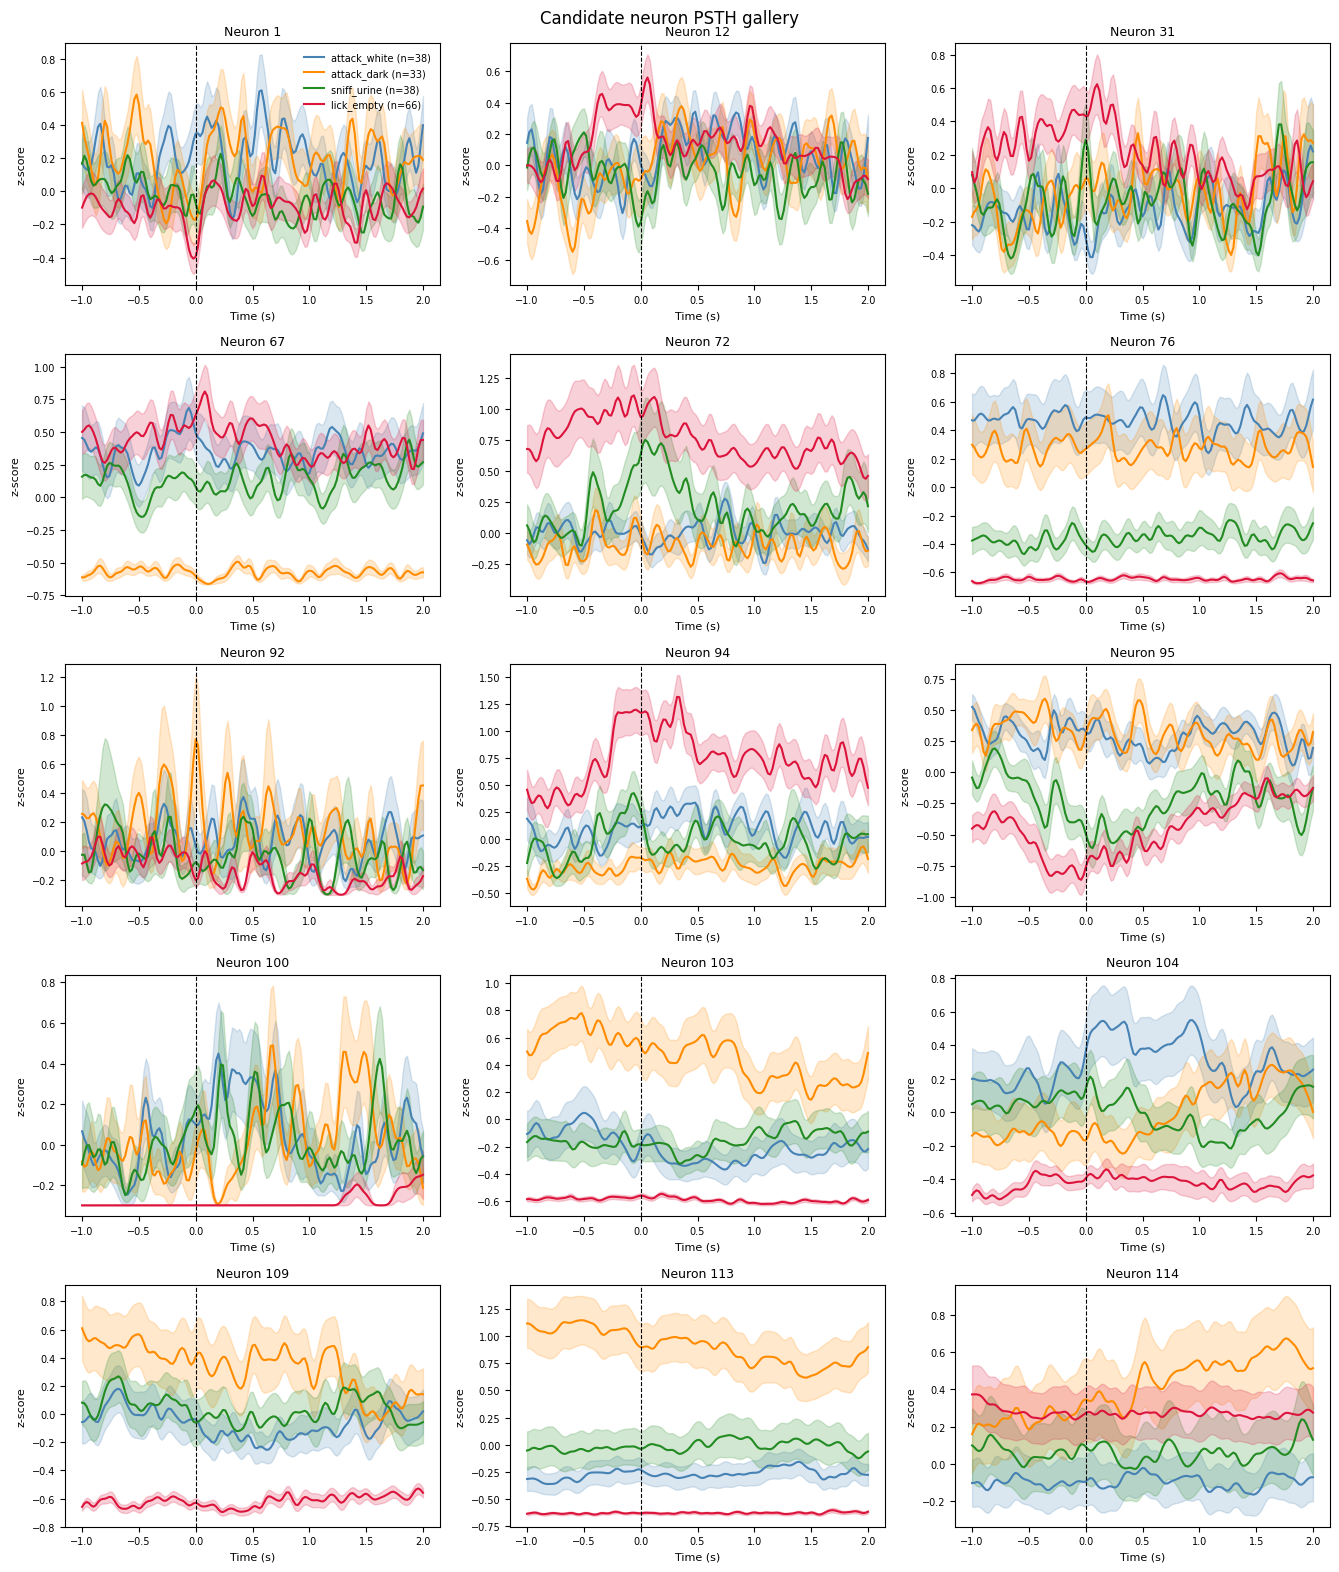

In [14]:
# =============================================================================
# SECTION 9 · Candidate PSTH gallery
# =============================================================================
time_event = np.arange(-pre_bins, post_bins + 1) / fs

event_specs = [
    ('attack_white', attack_onsets_white, 'steelblue'),
    ('attack_dark',  attack_onsets_dark,  'darkorange'),
    ('sniff_urine',  sniff_onsets,        'forestgreen'),
    ('lick_empty',   empty_onsets,        'crimson'),
]

# Auto-select candidate neurons from occupancy analysis
top_white = occ_white_df.sort_values(['q_fdr', 'effect_diff'],
                                      ascending=[True, False])['neuron'].head(15).tolist()
top_dark  = occ_dark_df.sort_values(['q_fdr', 'effect_diff'],
                                     ascending=[True, False])['neuron'].head(15).tolist()
candidate_neurons = sorted(set(top_white + top_dark))[:15]
print(f'Candidate neurons: {candidate_neurons}')


def plot_psth_panel(neuron_indices, n_cols=3, figsize_per=(4.5, 3.2)):
    n = len(neuron_indices)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per[0] * n_cols, figsize_per[1] * n_rows),
        squeeze=False
    )
    for ax_idx, nid in enumerate(neuron_indices):
        ax = axes[ax_idx // n_cols][ax_idx % n_cols]
        for label, onsets, color in event_specs:
            if len(onsets) == 0:
                continue
            wins = extract_event_windows(FRz, onsets, pre_bins, post_bins)
            mean = wins[:, nid, :].mean(axis=0)
            sem  = wins[:, nid, :].std(axis=0, ddof=1) / np.sqrt(max(wins.shape[0], 1))
            ax.plot(time_event, mean, color=color, label=f'{label} (n={wins.shape[0]})')
            ax.fill_between(time_event, mean - sem, mean + sem, alpha=0.2, color=color)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.set_title(f'Neuron {nid}', fontsize=9)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel('z-score', fontsize=8)
        ax.tick_params(labelsize=7)
        if ax_idx == 0:
            ax.legend(frameon=False, fontsize=7)
    # hide empty panels
    for ax_idx in range(len(neuron_indices), n_rows * n_cols):
        axes[ax_idx // n_cols][ax_idx % n_cols].axis('off')
    plt.suptitle('Candidate neuron PSTH gallery', fontsize=12)
    plt.tight_layout()
    plt.show()


plot_psth_panel(candidate_neurons)

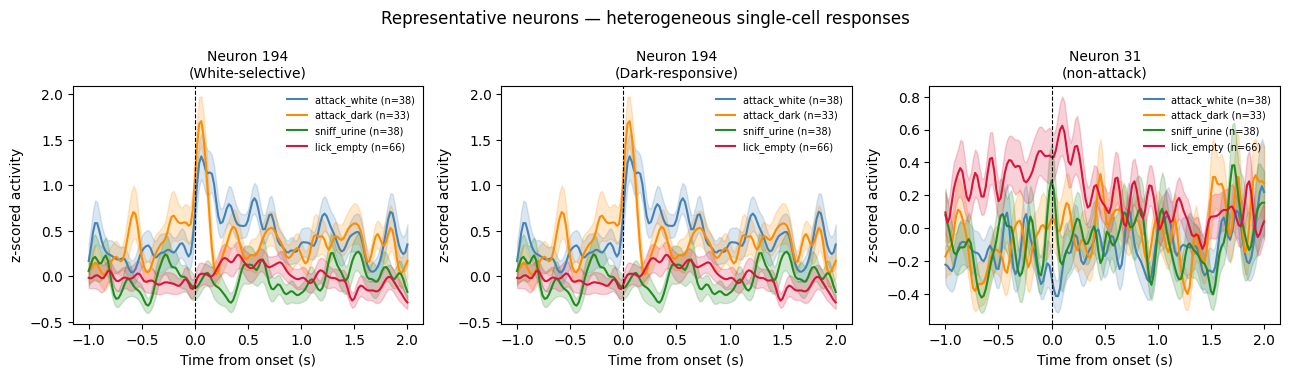

These three neurons illustrate that single-cell responses are heterogeneous.
No single neuron shows the clean context separation visible at the population level.


In [15]:
# --- Three representative neurons for PPT (side-by-side panel) ---
# Pick manually based on gallery above — edit these indices
# Criteria:
#   rep_1: White↑, Dark suppressed (context-differential)
#   rep_2: both White↑ and Dark↑ (behaviour-general)
#   rep_3: non-attack selective (e.g. sniff or lick)

# Default: use top White, top Dark, and a sniff-selective neuron
rep_white   = occ_white_df.sort_values('effect_diff', ascending=False)['neuron'].iloc[0]
rep_dark    = occ_dark_df.sort_values('effect_diff',  ascending=False)['neuron'].iloc[0]
# sniff-selective: high effect for sniff, low for attack
rep_sniff   = candidate_neurons[2] if len(candidate_neurons) > 2 else candidate_neurons[0]

rep_neurons = [int(rep_white), int(rep_dark), int(rep_sniff)]
rep_labels  = [
    f'Neuron {rep_neurons[0]}\n(White-selective)',
    f'Neuron {rep_neurons[1]}\n(Dark-responsive)',
    f'Neuron {rep_neurons[2]}\n(non-attack)',
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
for ax, nid, title in zip(axes, rep_neurons, rep_labels):
    for label, onsets, color in event_specs:
        if len(onsets) == 0:
            continue
        wins = extract_event_windows(FRz, onsets, pre_bins, post_bins)
        mean = wins[:, nid, :].mean(axis=0)
        sem  = wins[:, nid, :].std(axis=0, ddof=1) / np.sqrt(max(wins.shape[0], 1))
        ax.plot(time_event, mean, color=color, label=f'{label} (n={wins.shape[0]})')
        ax.fill_between(time_event, mean - sem, mean + sem, alpha=0.2, color=color)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel('z-scored activity')
    ax.legend(frameon=False, fontsize=7)

plt.suptitle('Representative neurons — heterogeneous single-cell responses', fontsize=12)
plt.tight_layout()
plt.show()

print('These three neurons illustrate that single-cell responses are heterogeneous.')
print('No single neuron shows the clean context separation visible at the population level.')

## 10. Summary & interpretation

In [16]:
# =============================================================================
# SECTION 10 · Summary table
# =============================================================================
summary_rows = [
    {'contrast':       'White attack vs non-attack (occupancy)',
     'n_sig':          occ_white_summary['n_significant'],
     'n_up':           occ_white_summary['n_up'],
     'n_down':         occ_white_summary['n_down'],
     'n_total':        n_neurons,
     'method':         'block circular-shift + FDR'},
    {'contrast':       'Dark attack vs non-attack (occupancy)',
     'n_sig':          occ_dark_summary['n_significant'],
     'n_up':           occ_dark_summary['n_up'],
     'n_down':         occ_dark_summary['n_down'],
     'n_total':        n_neurons,
     'method':         'block circular-shift + FDR'},
    {'contrast':       'White vs Dark (same behaviour, different context)',
     'n_sig':          int(n_sig_wd),
     'n_up':           int((df_wd['significant'] & (df_wd['effect_diff_a_minus_b'] > 0)).sum()),
     'n_down':         int((df_wd['significant'] & (df_wd['effect_diff_a_minus_b'] < 0)).sum()),
     'n_total':        n_neurons,
     'method':         'label-shuffle permutation + FDR'},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print()
print('=' * 70)
print('Interpretation — Single-neuron screening')
print('=' * 70)
print()
print('Supported:')
print(f'  Attack modulates individual neurons within both White and Dark phases.')
print(f'  White: {occ_white_summary["n_significant"]} neurons significant;'
      f' Dark: {occ_dark_summary["n_significant"]} neurons significant.')
print(f'  Responses are heterogeneous — no single "attack neuron" pattern.')
print()
print('Key negative finding:')
print(f'  White vs Dark contrast: {n_sig_wd} / {n_neurons} neurons significant after FDR.')
print('  The context separation visible at the population level (100% decoding)')
print('  is NOT carried by any individual cell — it is a population-level phenomenon.')
print()
print('Caveats:')
print('  - Single session; all results require cross-session replication.')
print('  - Attack bouts are clustered; clean-pre events are rare (see Section 8).')
print('  - Block circular-shift reduces but does not eliminate autocorrelation inflation.')

,contrast,n_sig,n_up,n_down,n_total,method
0,White attack vs non-attack (occupancy),1,1,0,218,block circular-shift + FDR
1,Dark attack vs non-attack (occupancy),0,0,0,218,block circular-shift + FDR
2,"White vs Dark (same behaviour, different context)",0,0,0,218,label-shuffle permutation + FDR



Interpretation — Single-neuron screening

Supported:
  Attack modulates individual neurons within both White and Dark phases.
  White: 1 neurons significant; Dark: 0 neurons significant.
  Responses are heterogeneous — no single "attack neuron" pattern.

Key negative finding:
  White vs Dark contrast: 0 / 218 neurons significant after FDR.
  The context separation visible at the population level (100% decoding)
  is NOT carried by any individual cell — it is a population-level phenomenon.

Caveats:
  - Single session; all results require cross-session replication.
  - Attack bouts are clustered; clean-pre events are rare (see Section 8).
  - Block circular-shift reduces but does not eliminate autocorrelation inflation.


In [17]:
# =============================================================================
# SECTION 11 · Save results
# =============================================================================
results_dir = Path('results_single_neuron')
results_dir.mkdir(exist_ok=True)

bout_summary.to_csv(results_dir / 'bout_summary.csv', index=False)
occupancy_summary.to_csv(results_dir / 'occupancy_summary.csv', index=False)
occ_white_df.to_csv(results_dir / 'occupancy_white_table.csv', index=False)
occ_dark_df.to_csv(results_dir / 'occupancy_dark_table.csv', index=False)
df_wd.to_csv(results_dir / 'white_vs_dark_table.csv', index=False)
summary_df.to_csv(results_dir / 'final_summary.csv', index=False)
clean_retention.to_csv(results_dir / 'clean_retention.csv', index=False)

print('Saved to:', results_dir.resolve())

Saved to: /Users/amadeus/Documents/MATLAB/ephysExercise/results_single_neuron
